In [1]:
import numpy as np
import matplotlib.pyplot as plt
import h5py
import hdf5plugin

In [3]:
data_path = "/Users/lvmeizhong/Desktop/denoise/17944364/000278.h5"

In [4]:
datah5 = h5py.File(data_path, 'r')
frames = datah5['entry/measurement/eiger500k/frames'][:]
scan = datah5['entry/description'][:]
print(scan)
datah5.close()

[b'npointflyscan sx 0.5 6.5 120 sy -2 5 140 0.1']


In [5]:
reshape_frames = np.reshape(frames, (141, 121, 512, 1028))

In [6]:
reshape_frames.shape

(141, 121, 512, 1028)

In [30]:
## first two are real space positions
## last two are detector positions

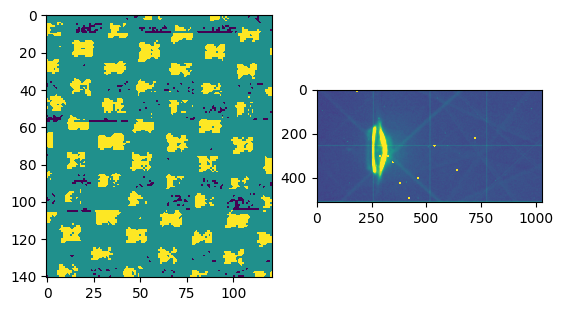

In [7]:
fig, ax = plt.subplots(1, 2)
total_Real = np.sum(reshape_frames, axis = (2, 3))
total_RSM = np.sum(reshape_frames, axis = (0, 1))
ax[0].imshow(total_Real, vmax = np.percentile(total_Real, 99))
ax[1].imshow(total_RSM, vmax = np.percentile(total_RSM, 99))

### Preprocessing + background separation cells
These cells clean a 2D detector/RSM image before denoising. They remove isolated bright spikes (hot pixels) using a median-based mask and replacement, then correct row/column striping by estimating an additive bias from border pixels. Next, they estimate a smooth background via iterative sigma-clipping and Gaussian smoothing, producing a background image and residual. A final plotting helper visualizes the input/background/residual for quick QA before feeding the corrected image into later steps (e.g., sigma-clip background, GAT/VST, or ML denoise).

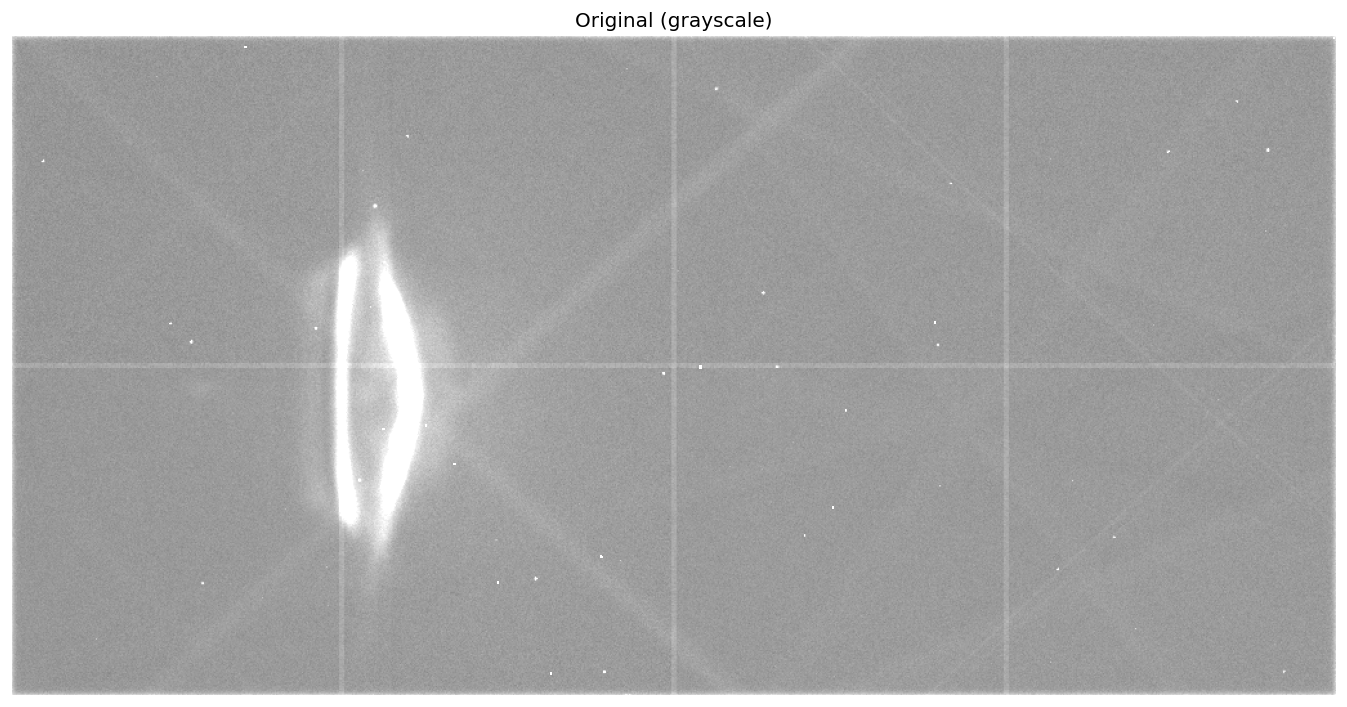

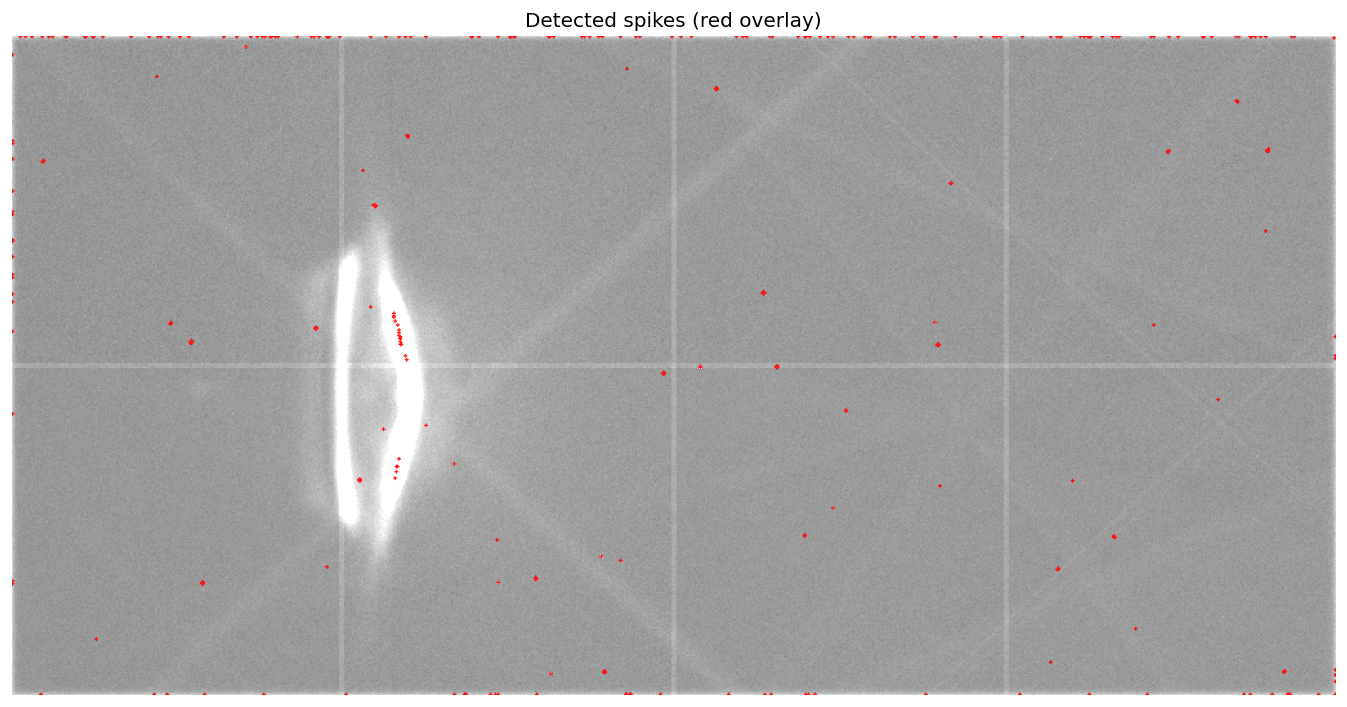

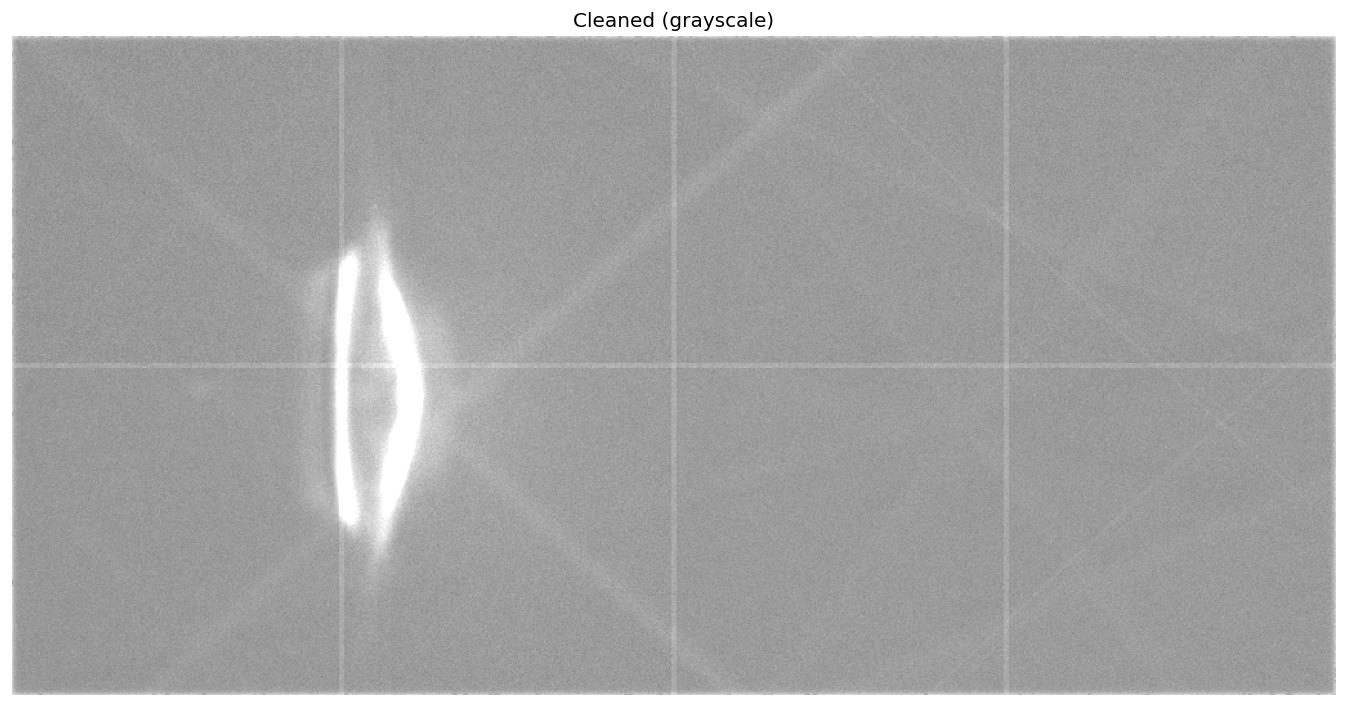

In [48]:
import numpy as np
from scipy.ndimage import median_filter, binary_dilation
import matplotlib.pyplot as plt


def despike_mask_2d(img, med_size=5, k=8.0, dilate=1):
    """
    Detect isolated bright spikes (hot pixels / cosmic-like hits) in a 2D image using
    a local median background and a robust (MAD-based) threshold.

    Parameters
    ----------
    img : array-like (H, W)
        Input 2D detector image (e.g., total_RSM).

    med_size : int
        Window size for the local median background (prefer odd values: 3/5/7).
        - Larger: smoother background estimate; may start to follow broad features.
        - Smaller: more local background; can be noisier and less stable.

    k : float
        Threshold in robust-sigma units computed from MAD of the residual.
        - Larger: more conservative (fewer pixels flagged).
        - Smaller: more aggressive (more pixels flagged; may remove real signal).
        Typical range: ~6 to 12.

    dilate : int
        Number of dilation iterations on the spike mask.
        - 0: no expansion.
        - Larger: expands the mask around spikes (safer margin, but masks more pixels).

    Returns
    -------
    mask : (H, W) bool
        True where pixels are flagged as spikes/outliers.

    bg : (H, W) float32
        Local median background estimate (same shape as img).
    """
    img = np.asarray(img, dtype=np.float32)

    # Local background estimate (median filter is robust to isolated outliers)
    bg = median_filter(img, size=med_size, mode="mirror")

    # Residual image: spikes become prominent after subtracting the local background
    resid = img - bg

    # Robust scale estimate via MAD (median absolute deviation)
    mad = np.median(np.abs(resid - np.median(resid)))
    sigma = 1.4826 * mad + 1e-12  # MAD->sigma for Gaussian-like noise; epsilon avoids zero

    # Spike mask: pixels whose residual is unusually large
    mask = resid > (k * sigma)

    # Optional expansion to cover neighboring pixels around spikes
    if dilate and dilate > 0:
        mask = binary_dilation(mask, iterations=dilate)

    return mask, bg


# Apply despike mask to total_RSM and create a cleaned image
# - total_RSM: assumed to exist from a previous cell
# - mask_hot: detected spike pixels
# - bg: local median background used for replacement
mask_hot, bg = despike_mask_2d(total_RSM, med_size=5, k=8.0, dilate=1)

total_RSM_clean = total_RSM.copy()
total_RSM_clean[mask_hot] = bg[mask_hot]  # Replace spikes using the local median estimate


# Visualization settings
# - Use a robust vmax so extreme spikes do not dominate the grayscale contrast
vmax = np.nanpercentile(total_RSM, 99)

# Build an RGBA overlay (red) that is visible only where mask_hot is True
overlay = np.zeros((*mask_hot.shape, 4), dtype=np.float32)
overlay[..., 0] = 1.0                              # Red channel
overlay[..., 3] = mask_hot.astype(np.float32) * 0.9 # Alpha (opacity) on masked pixels


def show_despike_image(img, title, overlay_rgba=None):
    """
    Display a 2D image in grayscale with an optional RGBA overlay.

    Parameters
    ----------
    img : array-like (H, W)
        Base image to display.

    title : str
        Figure title.

    overlay_rgba : array-like (H, W, 4) or None
        RGBA overlay (e.g., red spike mask). If provided, it is drawn on top.
    """
    fig, ax = plt.subplots(1, 1, figsize=(12, 6), dpi=120)
    ax.imshow(img, cmap="gray", vmin=0, vmax=vmax)

    if overlay_rgba is not None:
        ax.imshow(overlay_rgba)  # Draw RGBA overlay on top

    ax.set_title(title)
    ax.axis("off")
    plt.tight_layout()
    plt.show()


# Quick QA: original, mask overlay, and cleaned result
show_despike_image(total_RSM, "Original (grayscale)")
show_despike_image(total_RSM, "Detected spikes (red overlay)", overlay_rgba=overlay)
show_despike_image(total_RSM_clean, "Cleaned (grayscale)")


In [52]:
import numpy as np
from scipy.ndimage import median_filter

def robust_sigma(x):
    """
    Robust scale (noise) estimator using MAD (median absolute deviation).

    Notes
    -----
    - Ignores non-finite values (NaN/Inf).
    - Uses 1.4826 * MAD to approximate the standard deviation for Gaussian-like noise.
    - The small epsilon avoids returning exactly zero for near-constant inputs.
    """
    x = x[np.isfinite(x)]
    med = np.median(x)
    mad = np.median(np.abs(x - med))
    return 1.4826 * mad + 1e-12


def border_mask(shape, bw=40):
    """
    Create a boolean mask selecting a border frame around an image.

    Parameters
    ----------
    shape : tuple (H, W)
        Image shape.

    bw : int
        Border width in pixels.
        - Larger bw: more samples for bias estimation (more stable), but higher chance
          of including real signal near the edges.
        - Smaller bw: cleaner "background-only" assumption, but noisier estimates.

    Returns
    -------
    m : (H, W) bool
        True on border pixels, False elsewhere.
    """
    H, W = shape
    m = np.zeros((H, W), dtype=bool)
    m[:bw, :] = True
    m[-bw:, :] = True
    m[:, :bw] = True
    m[:, -bw:] = True
    return m


def destripe_from_border(img, bw=40, smooth=151, clip_k=4.0):
    """
    Remove row/column striping or tiling seams using border-only statistics.

    Method overview
    ---------------
    1) Use only border pixels (via `border_mask`) as a reference region.
    2) Sigma-clip border pixels to avoid contamination from bright spots or weak arcs.
    3) Estimate per-column and per-row additive offsets using medians (robust).
    4) Remove slow-varying trends from these offsets with a large 1D median filter.
    5) Reconstruct a 2D additive bias field and subtract it from the image.

    Parameters
    ----------
    img : array-like (H, W)
        Input 2D image.

    bw : int
        Border width used to estimate biases (see `border_mask`).

    smooth : int
        Median-filter window size for estimating the slow trend in the 1D bias curves.
        Must be an odd-ish large number for stable trend removal.
        - Larger: only very broad variations are treated as trend (keeps more mid-frequency bias).
        - Smaller: more variations are treated as trend (may under-correct wide seams).

    clip_k : float
        Sigma-clipping threshold applied to border pixels.
        - Larger: more conservative clipping (keeps more pixels; higher contamination risk).
        - Smaller: more aggressive clipping (cleaner border set; may become noisy if too few remain).

    Returns
    -------
    I_corr : (H, W) float
        Corrected image after subtracting the estimated additive bias.

    bias2d : (H, W) float
        Estimated 2D additive bias field (useful for QA/diagnostics).

    bm : (H, W) bool
        Border mask used to select reference pixels.
    """
    I = np.asarray(img, float).copy()
    bm = border_mask(I.shape, bw=bw)

    # Use border pixels only; sigma-clip to remove bright outliers (hot spots / weak arcs near edges)
    edge_vals = I[bm]
    med = np.nanmedian(edge_vals)
    sig = robust_sigma(edge_vals - med)

    # Keep finite border pixels that are not unusually bright
    keep = bm & np.isfinite(I) & (I < med + clip_k * sig)

    # Robust per-column and per-row bias estimates (median is stable against residual outliers)
    col_bias = np.nanmedian(np.where(keep, I, np.nan), axis=0)  # shape (W,)
    row_bias = np.nanmedian(np.where(keep, I, np.nan), axis=1)  # shape (H,)

    # High-pass: remove slow trend so we only keep stripe/seam-like high-frequency components
    col_bias_hp = col_bias - median_filter(col_bias, size=smooth, mode="reflect")
    row_bias_hp = row_bias - median_filter(row_bias, size=smooth, mode="reflect")

    # Build a 2D additive bias field and subtract it
    bias2d = row_bias_hp[:, None] + col_bias_hp[None, :]
    I_corr = I - bias2d

    return I_corr, bias2d, bm


# Input: image after hot-pixel/spike removal
img0 = total_RSM_clean

# Output: stripe/seam corrected image (img1) + bias field (bias2d) + border mask (bm)
img1, bias2d, bm = destripe_from_border(img0, bw=40, smooth=151, clip_k=4.0)



In [53]:
import numpy as np


def robust_sigma_mad(x):
    """
    Robust scale (noise) estimator using MAD (median absolute deviation).

    Parameters
    ----------
    x : array-like
        Input array (any shape). Non-finite values (NaN/Inf) are ignored.

    Returns
    -------
    sigma : float
        Robust estimate of the standard deviation (Gaussian-equivalent).
        Returns NaN if there are no finite values.
    """
    x = x[np.isfinite(x)]
    if x.size == 0:
        return np.nan

    med = np.median(x)
    mad = np.median(np.abs(x - med))
    return 1.4826 * mad + 1e-12  # MAD->sigma for Gaussian-like noise; epsilon avoids zero


def estimate_bg_sigma_clip(img, smooth_sigma=25, k=4.0, n_iter=4):
    """
    Estimate a smooth background by iterative sigma-clipping + Gaussian smoothing.

    Idea
    ----
    Treat strong positive features (peaks/arcs/spots) as outliers. Iteratively:
    1) Smooth the image to get a background guess.
    2) Compute residual = image - background.
    3) Identify "signal" pixels where residual > k * (robust sigma).
    4) Replace signal pixels with the current background and smooth again.

    Parameters
    ----------
    img : array-like (H, W)
        Input 2D image (can contain NaNs).

    smooth_sigma : float
        Gaussian smoothing sigma (in pixels) used to represent the background scale.
        - Larger: background becomes smoother (removes more mid-frequency structure).
        - Smaller: background follows the image more closely (risk absorbing weak signal).

    k : float
        Sigma-clipping threshold for labeling signal pixels from the residual.
        - Larger: more conservative masking (keeps more pixels as background).
        - Smaller: more aggressive masking (removes more weak features as "signal").

    n_iter : int
        Number of clipping + re-smoothing iterations.
        - More iterations: cleaner separation (up to a point), but slower.

    Returns
    -------
    bg : (H, W) float32
        Estimated smooth background.

    sig_mask : (H, W) bool
        Mask of pixels classified as "signal/outliers" (peaks/arcs/spots).

    resid : (H, W) float32
        Residual image = img - bg (contains both positive signal and remaining noise).
    """
    from scipy.ndimage import gaussian_filter

    I = np.asarray(img, dtype=np.float32)
    nan_mask = ~np.isfinite(I)

    # Initial background guess: smooth everything (fill NaNs with the global median)
    med0 = np.nanmedian(I)
    I0 = I.copy()
    I0[nan_mask] = med0
    bg = gaussian_filter(I0, smooth_sigma, mode="reflect")

    # Iteratively identify "signal" pixels and re-smooth only background pixels
    sig_mask = np.zeros_like(I, dtype=bool)
    for _ in range(n_iter):
        resid = I - bg
        sigma = robust_sigma_mad(resid)

        # Signal pixels: strong positive residuals (peaks/arcs/spots)
        sig_mask = np.isfinite(resid) & (resid > (k * sigma))

        # Re-estimate background by preventing signal pixels from biasing the smoothing
        work = I.copy()
        work[nan_mask] = bg[nan_mask]   # keep NaNs stable
        work[sig_mask] = bg[sig_mask]   # replace peaks with background estimate
        bg = gaussian_filter(work, smooth_sigma, mode="reflect")

    resid = I - bg
    return bg, sig_mask, resid


def estimate_bg_rolling_ball(img, radius=60):
    """
    Rolling-ball background estimator (useful for uneven illumination / slow background drift).

    Parameters
    ----------
    img : array-like (H, W)
        Input 2D image (can contain NaNs).

    radius : int
        Rolling-ball radius in pixels.
        - Larger: captures broader background variations (smoother bg).
        - Smaller: background follows more local structure.

    Returns
    -------
    bg : (H, W) float32
        Estimated background.

    resid : (H, W) float32
        Residual image = (NaN-filled img) - bg.
    """
    from skimage.restoration import rolling_ball

    I = np.asarray(img, dtype=np.float32)
    med0 = np.nanmedian(I)
    I0 = I.copy()
    I0[~np.isfinite(I0)] = med0

    bg = rolling_ball(I0, radius=radius)
    resid = I0 - bg
    return bg, resid


def estimate_bg_morph_opening(img, size=(51, 51)):
    """
    Morphological opening as a background estimator (fast; removes small bright structures).

    Parameters
    ----------
    img : array-like (H, W)
        Input 2D image (can contain NaNs).

    size : tuple of int (h, w)
        Structuring element size for grey opening.
        - Larger: removes larger bright features (more aggressive background).
        - Smaller: preserves more small-scale structure (less aggressive).

    Returns
    -------
    bg : (H, W) float32
        Estimated background.

    resid : (H, W) float32
        Residual image = (NaN-filled img) - bg.
    """
    from scipy.ndimage import grey_opening

    I = np.asarray(img, dtype=np.float32)
    med0 = np.nanmedian(I)
    I0 = I.copy()
    I0[~np.isfinite(I0)] = med0

    bg = grey_opening(I0, size=size)
    resid = I0 - bg
    return bg, resid


# -----------------------------
# USAGE:
# -----------------------------

# Tunable parameters:
# - smooth_sigma: background smoothness scale (pixels)
# - k: clipping threshold in robust-sigma units
# - n_iter: number of refinement iterations
smooth_sigma = 40
k = 3.5
n_iter = 4

bg, sig_mask, resid = estimate_bg_sigma_clip(
    img1, smooth_sigma=smooth_sigma, k=k, n_iter=n_iter
)


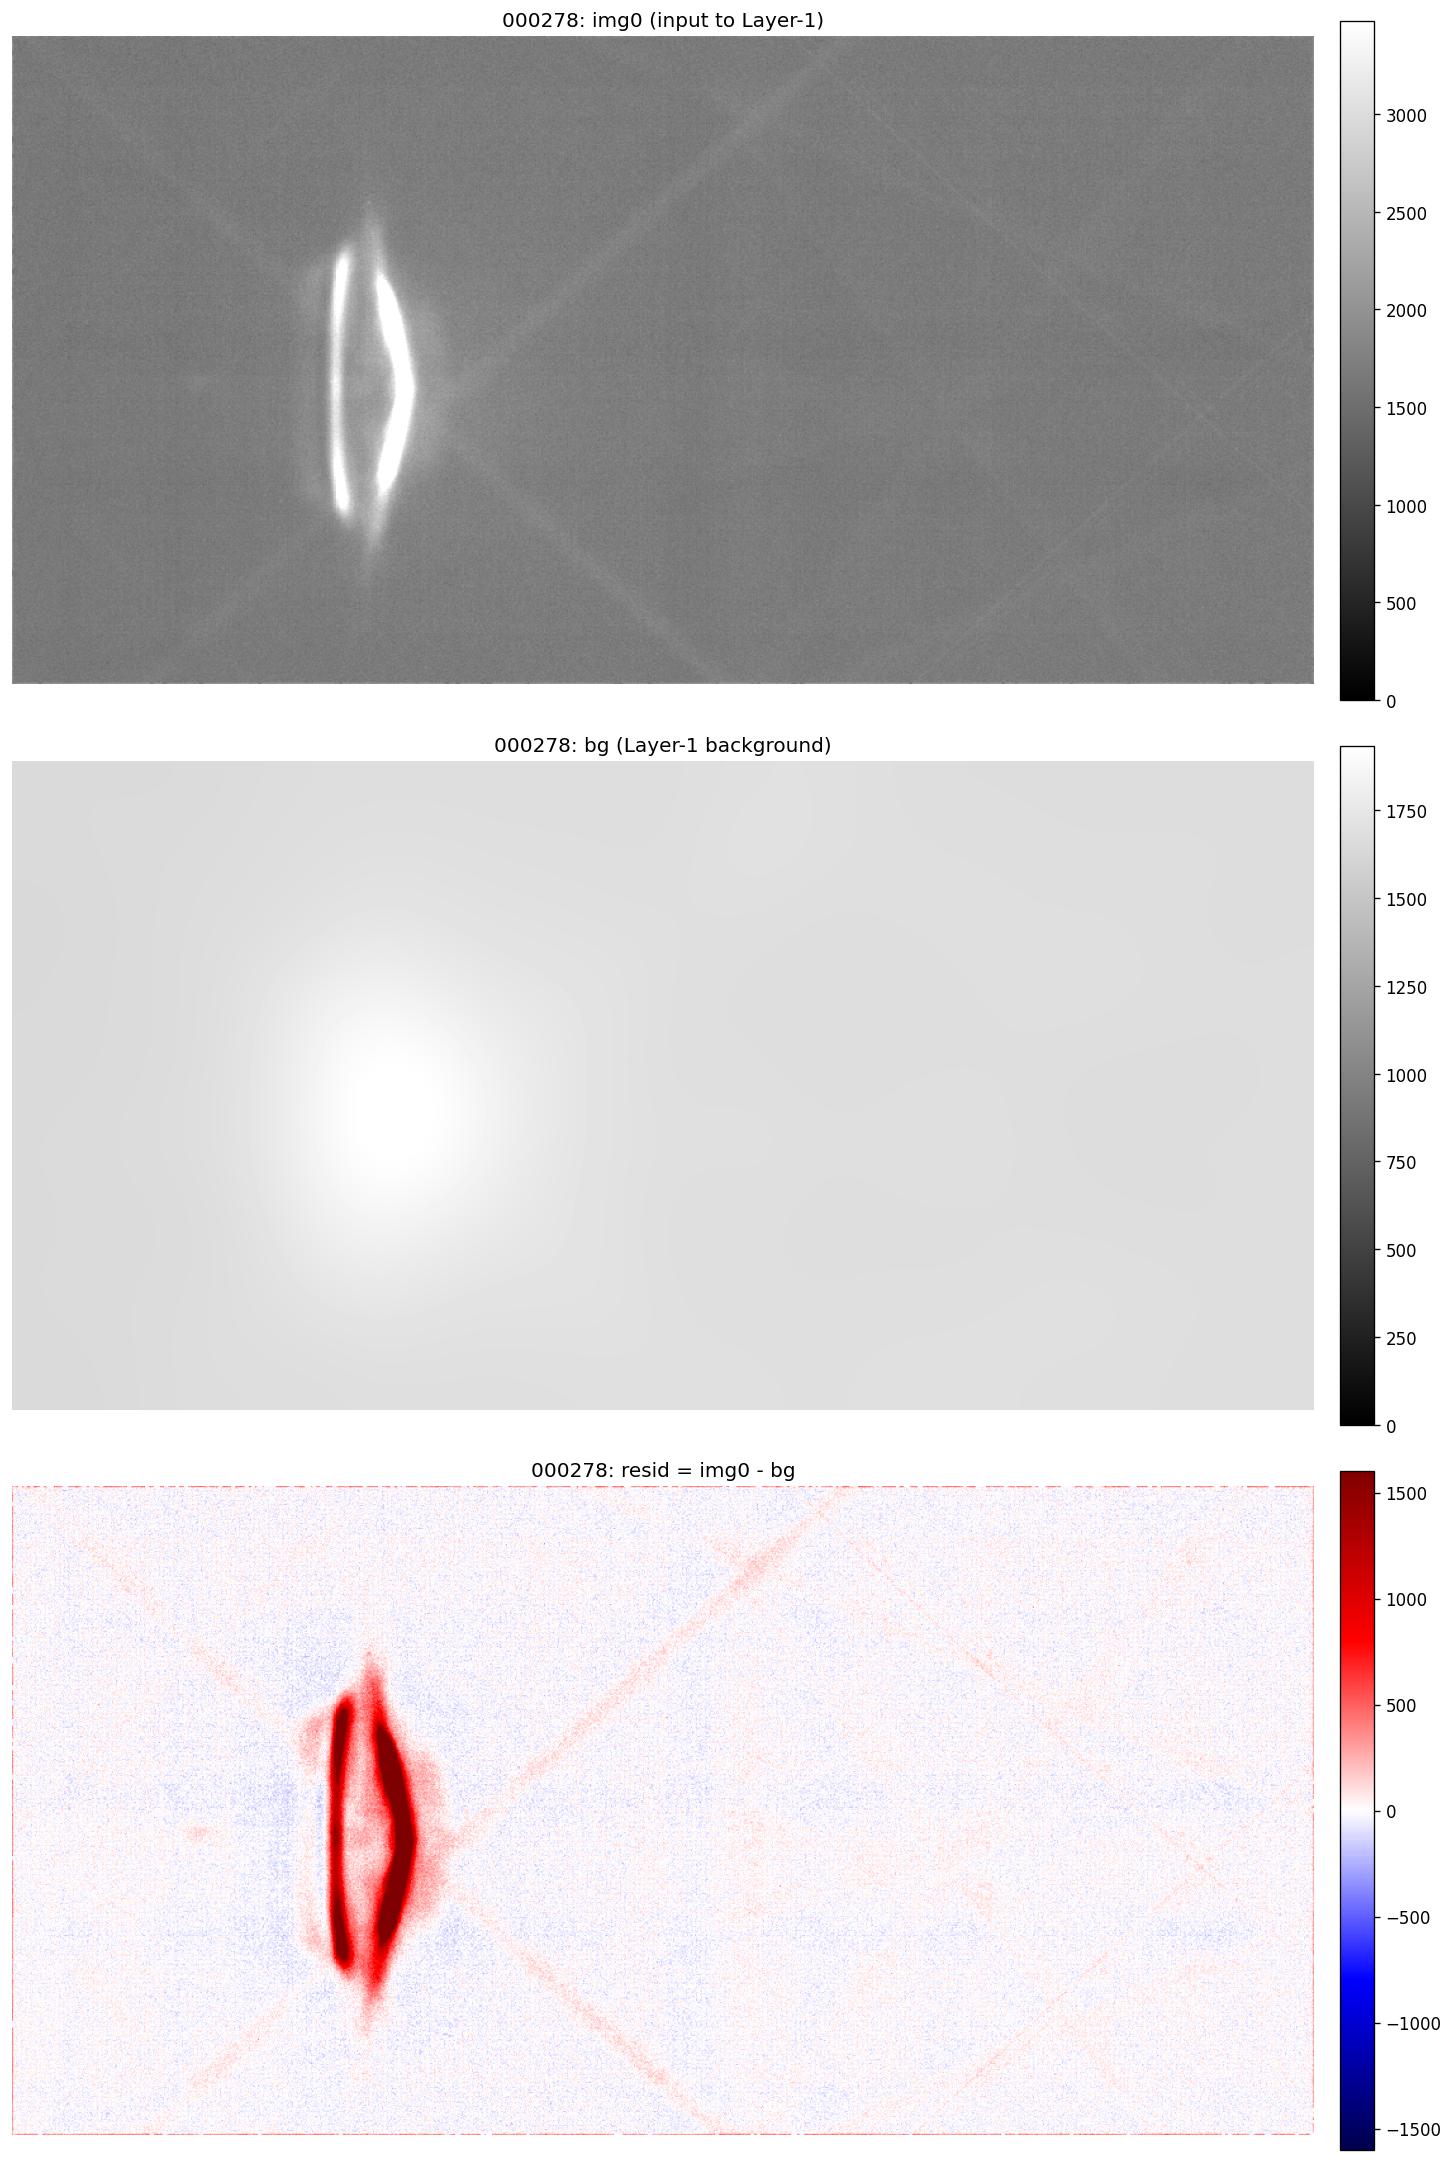

In [54]:
import numpy as np
import matplotlib.pyplot as plt


def plot_background_and_residual(img0, bg, resid, sig_mask, vpercent=99.5, title_prefix=""):
    """
    Visual QA helper for Layer-1 background separation.

    This function displays three vertically stacked panels:
      1) img0   : input image entering Layer-1 (e.g., after despike + destripe)
      2) bg     : estimated smooth background from Layer-1
      3) resid  : residual = img0 - bg (should highlight peaks/arcs/spots)

    Parameters
    ----------
    img0 : array-like (H, W)
        Input image used for background estimation (typically `img1`).

    bg : array-like (H, W)
        Estimated background image.

    resid : array-like (H, W)
        Residual image (img0 - bg).

    sig_mask : array-like (H, W) bool
        Mask of pixels classified as signal/outliers by sigma-clipping.
        Note: This function currently does not draw the mask overlay; it is kept
        as an input so you can easily add overlay later if needed.

    vpercent : float
        Percentile for display scaling.
        - Larger (e.g., 99.9): allows brighter peaks to show but can compress contrast.
        - Smaller (e.g., 99.0): increases contrast for mid-range values but can saturate peaks.

    title_prefix : str
        Optional prefix added to each subplot title (useful for scan IDs).
    """
    img0 = np.asarray(img0, dtype=float)
    bg = np.asarray(bg, dtype=float)
    resid = np.asarray(resid, dtype=float)
    sig_mask = np.asarray(sig_mask, dtype=bool)

    # Robust display limits so a few extreme pixels do not dominate contrast
    vmax0 = np.nanpercentile(img0, vpercent)
    vmaxb = np.nanpercentile(bg, vpercent)
    vr = np.nanpercentile(np.abs(resid), vpercent)  # symmetric range for diverging colormap

    # 3 rows x 1 column: one image per row
    fig, ax = plt.subplots(
        nrows=3, ncols=1,
        figsize=(12, 18), dpi=120,
        constrained_layout=True
    )

    im0 = ax[0].imshow(img0, cmap="gray", vmin=0, vmax=vmax0)
    ax[0].set_title(f"{title_prefix}img0 (input to Layer-1)")
    ax[0].axis("off")
    fig.colorbar(im0, ax=ax[0], fraction=0.046, pad=0.02)

    im1 = ax[1].imshow(bg, cmap="gray", vmin=0, vmax=vmaxb)
    ax[1].set_title(f"{title_prefix}bg (Layer-1 background)")
    ax[1].axis("off")
    fig.colorbar(im1, ax=ax[1], fraction=0.046, pad=0.02)

    im2 = ax[2].imshow(resid, cmap="seismic", vmin=-vr, vmax=vr)
    ax[2].set_title(f"{title_prefix}resid = img0 - bg")
    ax[2].axis("off")
    fig.colorbar(im2, ax=ax[2], fraction=0.046, pad=0.02)

    plt.show()


# -----------------------------
# Example usage:
# -----------------------------
bg, sig_mask, resid = estimate_bg_sigma_clip(img1, smooth_sigma=smooth_sigma, k=k, n_iter=n_iter)
plot_background_and_residual(img1, bg, resid, sig_mask, title_prefix="000278: ")
